In [1]:
from analyzer import SpatialMetricsAnalyzer, analyze
from visualizer import SpatialMetricsVisualizer, visualize_all_metrics

In [2]:
data_dir = "C:/Users/jordan/Documents/GitHub/CoralNet-Toolbox/data/taglab/spatial_metrics"

image_path = f"{data_dir}/Plot18_RGB.png"
elevation_path = f"{data_dir}/Plot18_DEM.tiff"
mask_path = f"{data_dir}/masks/Plot18_RGB.png"
geojson_path = f"{data_dir}/annotations.geojson"

In [3]:
data_dir = "D:/DSM/sandstar_subset/Not_Cleaned_Tiepoints"

image_path = f"{data_dir}/orthomosaic.tif"
elevation_path = f"{data_dir}/dem.tif"
mask_path = f"{data_dir}/masks/orthomosaic.png"
geojson_path = f"{data_dir}/annotations.geojson"

In [4]:
analyzer = SpatialMetricsAnalyzer(
    image_path=image_path,
    elevation_path=elevation_path,
    mask_path=mask_path,
    geojson_path=geojson_path
)

[INFO] CRS is geographic or missing, using scale_factor
[INFO] CRS is geographic or missing, using scale_factor
[INFO] CRS is geographic or missing, using scale_factor
[INFO] Using provided scale_factor: 1.0 m/px
SpatialMetricsAnalyzer Initialized
  Image:      D:\DSM\sandstar_subset\Not_Cleaned_Tiepoints\orthomosaic.tif
  Elevation:  D:\DSM\sandstar_subset\Not_Cleaned_Tiepoints\dem.tif
  Mask:       D:\DSM\sandstar_subset\Not_Cleaned_Tiepoints\masks\orthomosaic.png
  GeoJSON:    D:\DSM\sandstar_subset\Not_Cleaned_Tiepoints\annotations.geojson
  Scale:      1.000000 meters/pixel


c:\Users\jordan\miniconda3\envs\coralnet10\lib\site-packages\rasterio\__init__.py:368: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


In [5]:
summary_df, report = analyzer.generate_report()


GENERATING SPATIAL METRICS REPORT

Analyzing 14 metric categories...



Computing metrics:   7%|▋         | 1/14 [00:00<00:01,  7.20metric/s]


[METRIC] Calculating Pixel Coverage Fraction (PCF)...
[INFO] Loading semantic segmentation mask raster...
[INFO] Semantic classes present: [0 1 2 3]
[INFO] Semantic mask loaded: shape=(3639, 4231)
  → PCF: 4.52% (696134.0000 m² / 15396609.0000 m²)

[METRIC] Calculating Resource Abundance...
[INFO] Loading GeoJSON polygons...


Parsing polygons: 100%|██████████| 29/29 [00:00<?, ?feature/s]


[INFO] Loaded 29 valid polygons
  → Count: 29 objects
  → Abundance: 0.0000 objects/m² (0.00 per 100m²)

[METRIC] Calculating Spatial Homogeneity (Quadrat Analysis, 4x4)...


...

[INFO] Found classes: ['organism', 'nodule']
  Creating 4x4 grid
  Identifying species in each grid cell...


Computing metrics: 100%|██████████| 14/14 [00:02<00:00,  6.80metric/s]


  Computing pairwise distances...
  → Mean distance (jaccard): 0.5667
  → Cells with biology: 7/16
  → Interpretation: High turnover: strong community drift across site

[METRIC] Calculating Morphology Statistics...


Analyzing shapes: 100%|██████████| 29/29 [00:00<?, ?polygon/s]

  → Analyzed 29 polygons
  → Circularity: mean=0.686, std=0.159
  → Solidity: mean=0.900, std=0.147
  → OBB Aspect Ratio: mean=0.783, std=0.133

REPORT SUMMARY
Computed: 12 metrics
Skipped: 3 metrics

Key Results:
----------------------------------------
  pcf                       pcf_percent          = 4.5213
  abundance                 count                = 29.0000
  spatial_homogeneity       vmr                  = 3.0322
  nearest_neighbor_distance mean_nnd_m           = 0.0335
  passability               max_passage_diameter_m = 486.6210
  ripleys_k                 max_clustering_radius_m = 0.1655
  clark_evans               clark_evans_r        = 0.6452
  protrusion                mean_protrusion_m    = 0.0021
  embedment_angle           mean_contact_angle_deg = 0.8944
  bivariate_ripleys_k       n_class_a            = 27.0000
  beta_diversity_turnover   mean_distance        = 0.5667
  morphology                circularity_mean     = 0.6858


[INFO] Loading elevation raster...
[WARNING] Elevation resolution (1551, 1806) differs from orthomosaic (3639, 4231). Resampling DEM to orthomosaic pixel grid.
[INFO] Resampling elevation from (1551, 1806) to (3639, 4231) (zoom factors: 2.346, 2.343)
[INFO] Elevation resampled: new shape=(3639, 4231)
[INFO] Elevation loaded: shape=(3639, 4231)
[INFO] ASSUMPTION: Elevation units are METERS (matching XY scale)

GENERATING ALL METRIC VISUALIZATIONS


[METRIC] Calculating Nearest Neighbor Distance (method=edge)...


Computing edge distances: 100%|██████████| 29/29 [00:00<00:00, 1814.09polygon/s]

  → Mean NND: 0.0335 m
  → Median NND: 0.0273 m
  → Range: [0.0000, 0.0891] m



[METRIC] Calculating Passability Index...
  Computing Euclidean Distance Transform...
  → Max passage diameter: 486.6210 m
  → Max passage location: (3813.0000, 1627.0000) m
  → Mean clearance: 61.3648 m
  → Free space: 80.00%

[METRIC] Calculating Morphology Statistics...


Analyzing shapes: 100%|██████████| 29/29 [00:00<00:00, 9628.34polygon/s]

...

  → Analyzed 29 polygons
  → Circularity: mean=0.686, std=0.159
  → Solidity: mean=0.900, std=0.147
  → OBB Aspect Ratio: mean=0.783, std=0.133



VISUALIZING PROTRUSION (STICK-UP HEIGHT)

[METRIC] Calculating Protrusion (Stick-up Height)...
[INFO] Resampling elevation from (1551, 1806) to (3639, 4231) (zoom factors: 2.346, 2.343)
  Estimating virtual seafloor plane...
  Calculating per-object protrusion for 29 objects...


Per-object stats: 100%|██████████| 29/29 [00:00<?, ?obj/s]

  → Mean protrusion: 0.0021 m (0.21 cm)
  → Max protrusion: 12.7103 m (1271.03 cm)
  → Seafloor baseline: -12.7103 m
[INFO] Auto-calculated stride=3 for safe 3D rendering
[RENDER] Generating 2D suite for protrusion...


[RENDER] Generating 3D clean figure for protrusion...
  ✓ Saved: protrusion_3d_clean.png
[RENDER] Generating 3D overlay figure for protrusion...
  ✓ Saved: protrusion_3d_overlay.png

VISUALIZING EMBEDMENT ANGLE (CONTACT SLOPE)
[INFO] Auto-calculated stride=3 for safe 3D rendering
[RENDER] Generating 2D suite for embedment_angle...
[ERROR] Embedment Angle visualization failed: name 'meters_per_pixel' is not defined

VISUALIZATION GENERATION COMPLETE


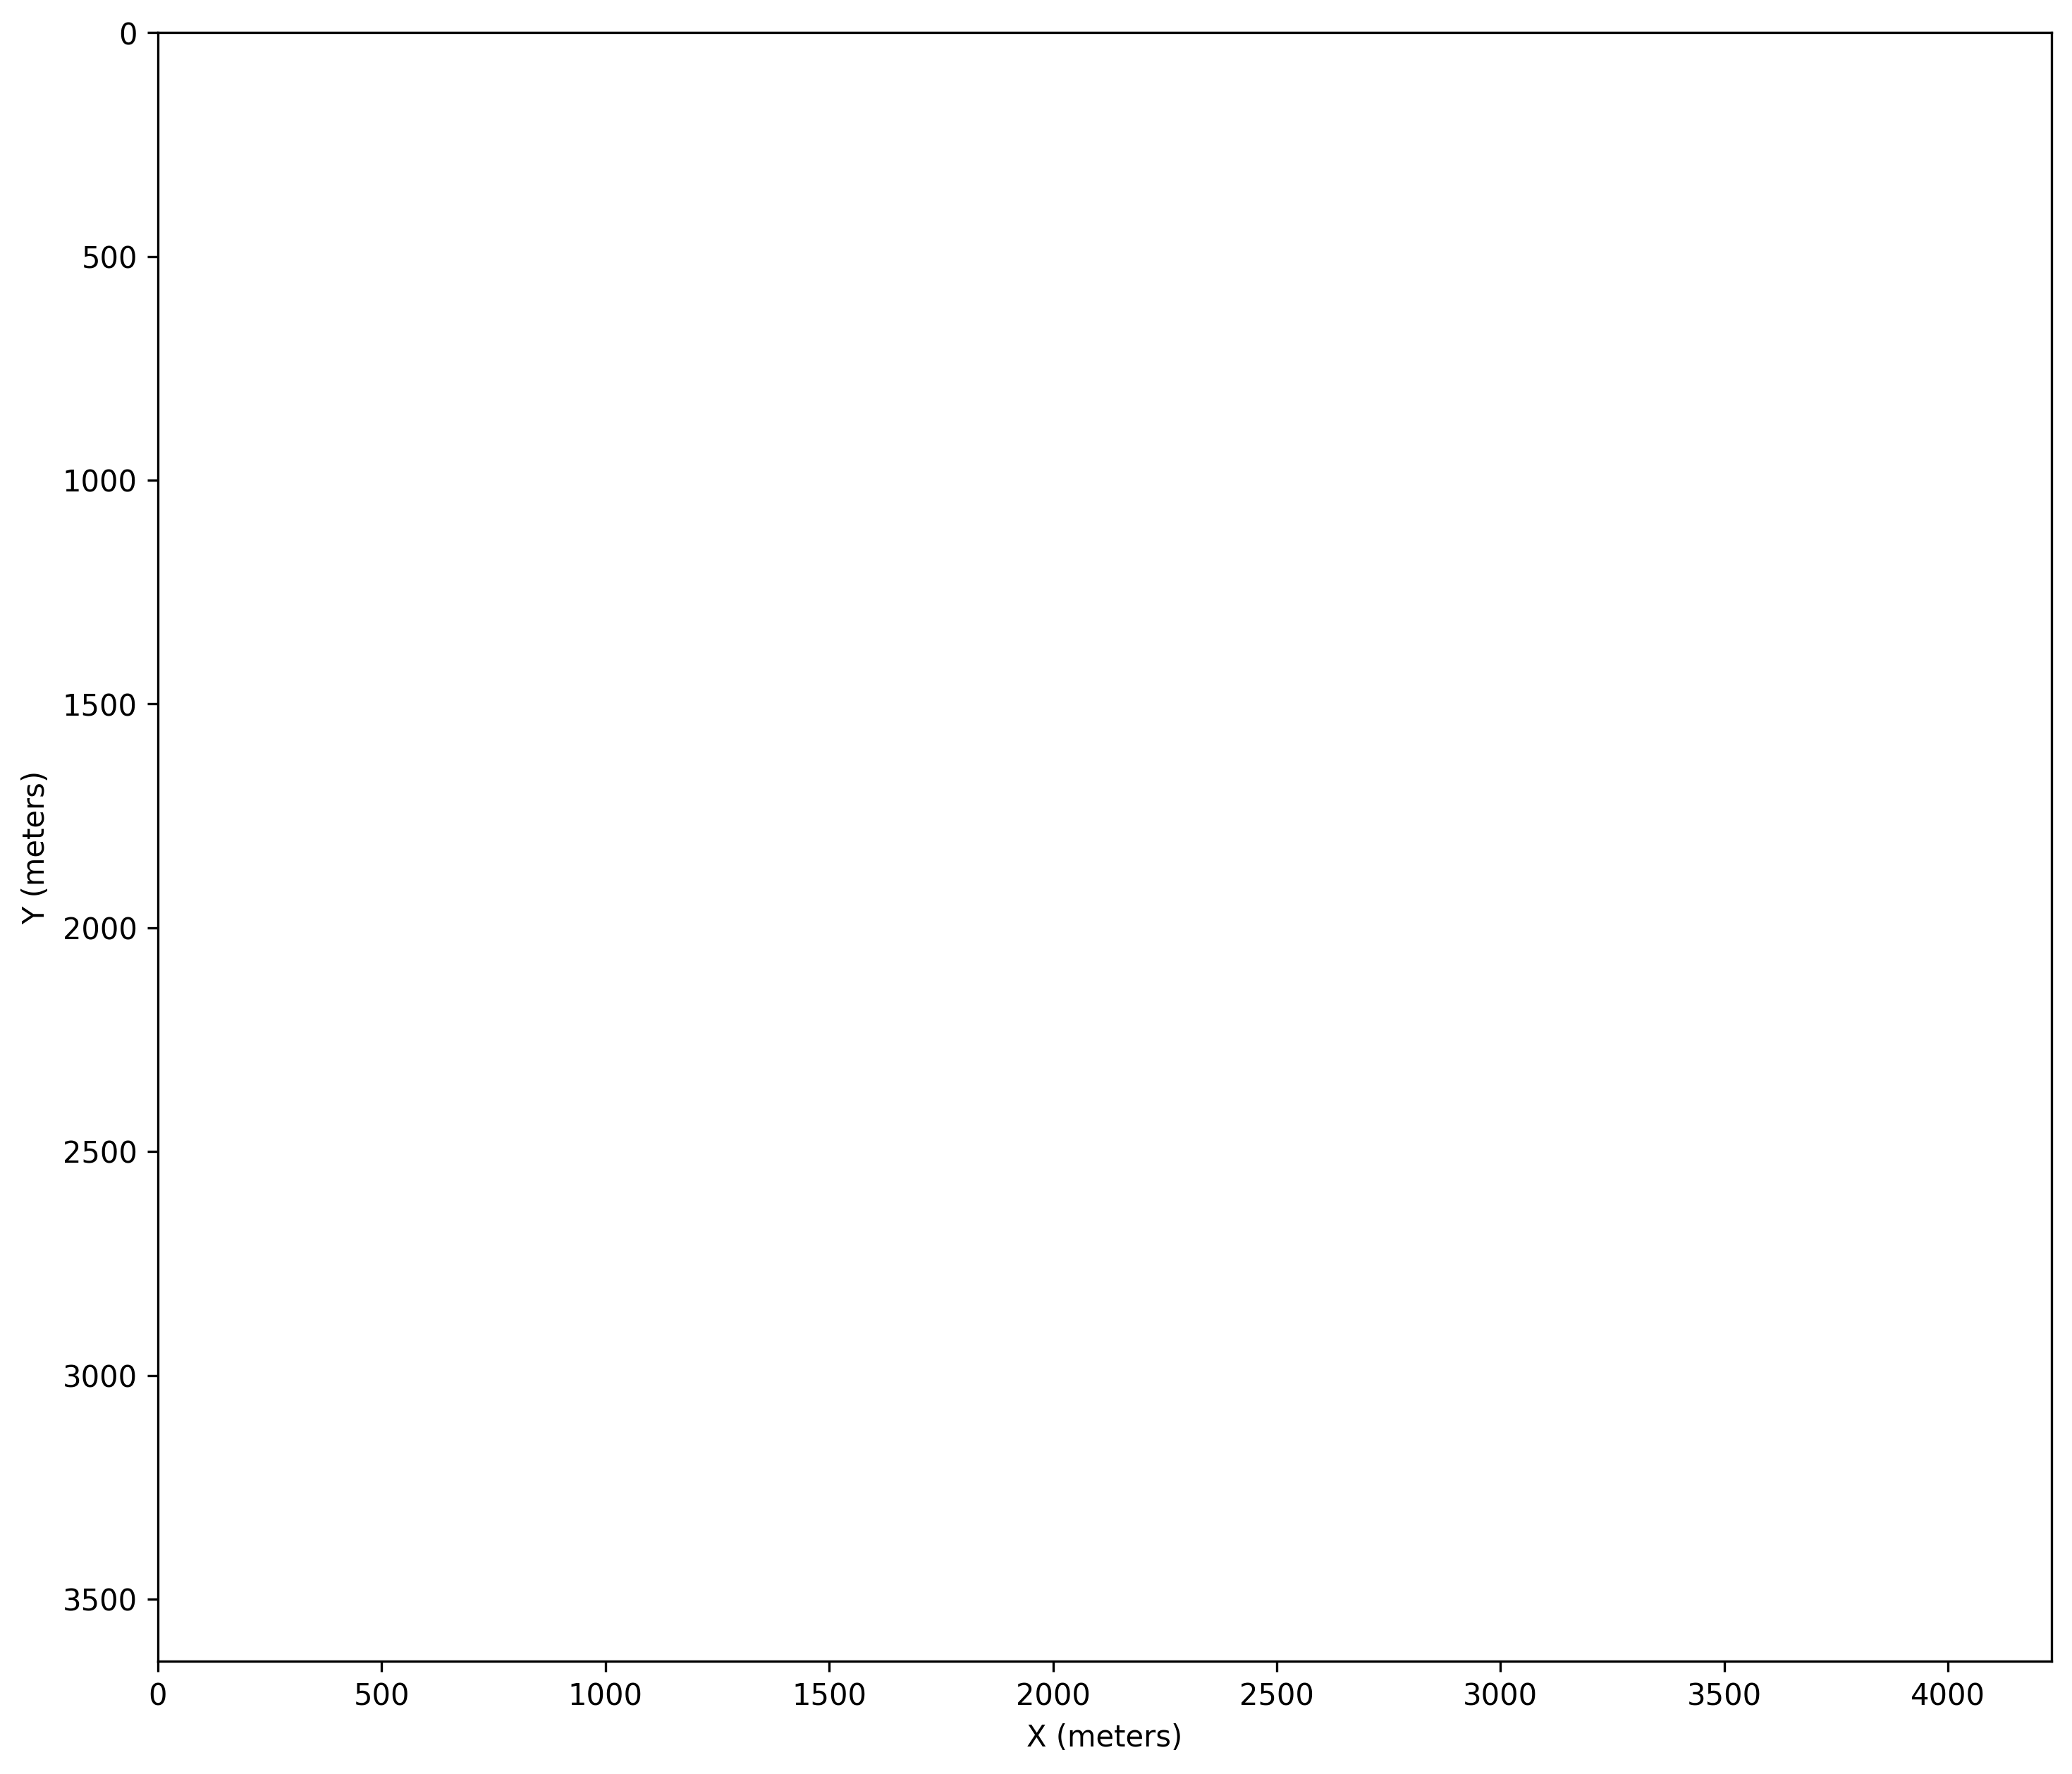

In [6]:
results = visualize_all_metrics(analyzer, output_dir="../figures")